# Project 1 – Exercise 2

Define the data :

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Given data
t = np.array([0.00, 0.54, 0.90, 1.23, 1.58, 1.95, 2.33, 2.70])
X = np.array([15.5, 23.0, 30.0, 38.8, 48.5, 58.3, 61.3, 62.5])
S = np.array([137, 114, 90, 43, 29, 9, 2])

# for plotting, we need to extend S same length as t
S_plot = np.append(S, S[-1])

## Part A - Plots

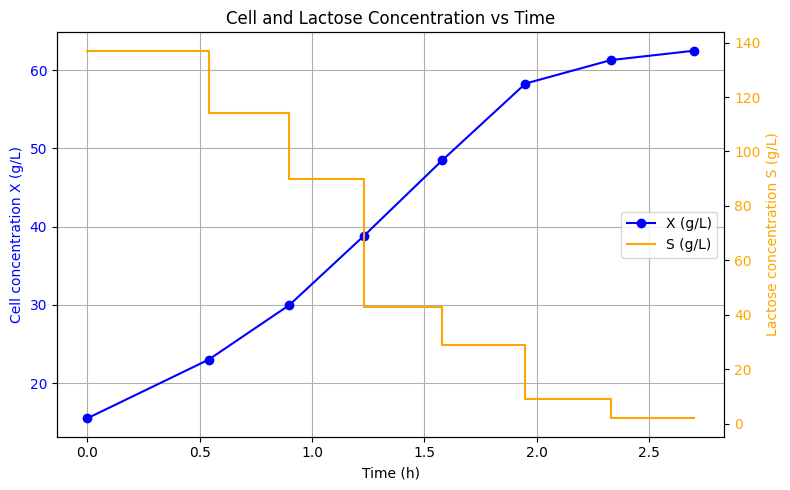

In [2]:
fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()

# simple plot for X over time
ax1.plot(t, X, marker="o", color="blue", label="X (g/L)")

# step plot for S over time (post to change step at the end of the interval)
ax2.step(t, S_plot, "-", color="orange", where="post", label="S (g/L)")

# labels
ax1.set_xlabel("Time (h)")
ax1.set_ylabel("Cell concentration X (g/L)", color="blue")
ax2.set_ylabel("Lactose concentration S (g/L)", color="orange")
ax1.tick_params(axis="y", labelcolor="blue")
ax2.tick_params(axis="y", labelcolor="orange")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right")
ax1.set_title("Cell and Lactose Concentration vs Time")
ax1.grid(True)
plt.tight_layout()
plt.show()

From this, we can identify the phases :

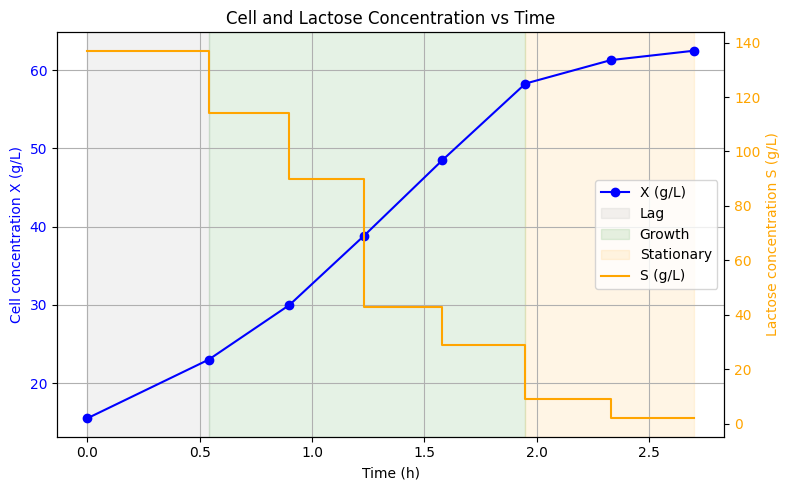

In [3]:
fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()

# simple plot for X over time
ax1.plot(t, X, marker="o", color="blue", label="X (g/L)")

# step plot for S over time
# here, step with "post" to change step at the end of the interval t
ax2.step(t, S_plot, "-", color="orange", where="post", label="S (g/L)")

# labels
ax1.set_xlabel("Time (h)")
ax1.set_ylabel("Cell concentration X (g/L)", color="blue")
ax2.set_ylabel("Lactose concentration S (g/L)", color="orange")
ax1.tick_params(axis="y", labelcolor="blue")
ax2.tick_params(axis="y", labelcolor="orange")

# we add phases of growth here
ax1.axvspan(0, 0.54, alpha=0.1, color="gray", label="Lag")
ax1.axvspan(0.54, 1.95, alpha=0.1, color="green", label="Growth")
ax1.axvspan(1.95, 2.70, alpha=0.1, color="orange", label="Stationary")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right")
ax1.set_title("Cell and Lactose Concentration vs Time")
ax1.grid(True)
plt.tight_layout()
plt.show()

## Part A - Lineweaver-Burke plot, Ks and mu max

We compute mu in each time interval using the formula given:

$$\mu = \frac{1}{X_{min}} \frac{dX}{dt}$$

where $X_{min}$ is the cell concentration at the start of the interval.

We then use only the exponential phase data (t = 0.54 to 1.95 h) to build the Lineweaver-Burke plot (1/mu vs 1/S) and extract Ks and mu max from the linear fit:

$$\frac{1}{\mu} = \frac{K_s}{\mu_{max}} \cdot \frac{1}{S} + \frac{1}{\mu_{max}}$$

In [4]:
# Compute mu for each of the 7 intervals
# mu_i = (1/X_min) * (dX/dt)
mu = np.zeros(7)
for i in range(7):
    dX_dt = (X[i+1] - X[i]) / (t[i+1] - t[i])
    X_min = X[i]
    mu[i] = dX_dt / X_min

# create a df to see the results
data = {
    "Interval": [f"{t[i]} - {t[i+1]} h" for i in range(7)],
    "S (g/L)": S,
    "mu (1/h)": mu
}
df = pd.DataFrame(data)
df

,Interval,S (g/L),mu (1/h)
0,0.0 - 0.54 h,137,0.896057
1,0.54 - 0.9 h,114,0.845411
2,0.9 - 1.23 h,90,0.888889
3,1.23 - 1.58 h,43,0.714286
4,1.58 - 1.95 h,29,0.546113
5,1.95 - 2.33 h,9,0.135416
6,2.33 - 2.7 h,2,0.052908


In [5]:
# We want only exponential phase: index 1 to 4
exp_indices = [1, 2, 3, 4]

S_exp = S[exp_indices]
mu_exp = mu[exp_indices]

one_over_S = 1.0 / S_exp
one_over_mu = 1.0 / mu_exp

# exp dataframe
exp_data = {
    "S (g/L)": S_exp,
    "mu (1/h)": mu_exp,
    "1/S (L/g)": one_over_S,
    "1/mu (h)": one_over_mu
}
df_exp = pd.DataFrame(exp_data)
df_exp

,S (g/L),mu (1/h),1/S (L/g),1/mu (h)
0,114,0.845411,0.008772,1.182857
1,90,0.888889,0.011111,1.125000
2,43,0.714286,0.023256,1.400000
3,29,0.546113,0.034483,1.831122


In [6]:
# Linear regression: 1/mu = (Ks/mu_max)*(1/S) + 1/mu_max
slope, intercept = np.polyfit(one_over_S, one_over_mu, 1)

mu_max = 1 / intercept
Ks = slope * mu_max

print(f"slope = {slope}, intercept = {intercept}")
print(f"mu_max = {mu_max} h^-1")
print(f"Ks = {Ks} g/L")

slope = 26.154763358435808, intercept = 0.8772011647466572
mu_max = 1.1399893663944325 h^-1
Ks = 29.816152109179555 g/L


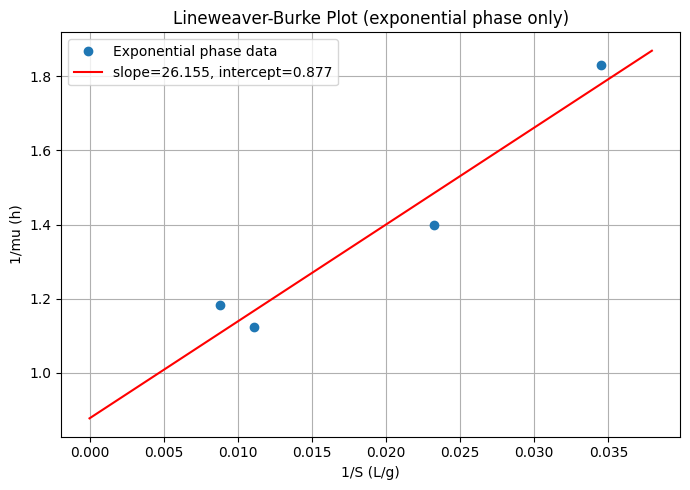

y-intercept = 1/mu_max -> mu_max = 1.1399893663944325 h^-1
slope = Ks/mu_max -> Ks = 29.816152109179555 g/L


In [7]:
# Lineweaver-burke plot
one_over_S_line = np.linspace(0, max(one_over_S) * 1.1, 100)
one_over_mu_fit = slope * one_over_S_line + intercept

plt.figure(figsize=(7, 5))
plt.plot(one_over_S, one_over_mu, "o", label="Exponential phase data")
plt.plot(one_over_S_line, one_over_mu_fit, "-", color="red", label=f"slope={slope:.3f}, intercept={intercept:.3f}")



plt.xlabel("1/S (L/g)")
plt.ylabel("1/mu (h)")
plt.title("Lineweaver-Burke Plot (exponential phase only)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"y-intercept = 1/mu_max -> mu_max = {mu_max} h^-1")
print(f"slope = Ks/mu_max -> Ks = {Ks} g/L")

## Part B - Mass doubling time

For exponential growth, X follows

$$
X(t) = X_0 e^{\mu t}
$$

If X doubles ($X = 2X_0$), the doubling time is

$$
t_d = \frac{\ln(2)}{\mu}
$$

According to the Monod equation (see slide below)

$$
\mu = \mu_{\max} \frac{S}{K_s + S}
$$

the growth rate approaches $\mu_{\max}$ when the substrate concentration is high ($S \gg K_s$).  
In the exponential phase, we assume that growth is not substrate-limited, so

$$
\mu \approx \mu_{\max}.
$$

Therefore :

$$
t_d = \frac{\ln(2)}{\mu_{\max}}.
$$

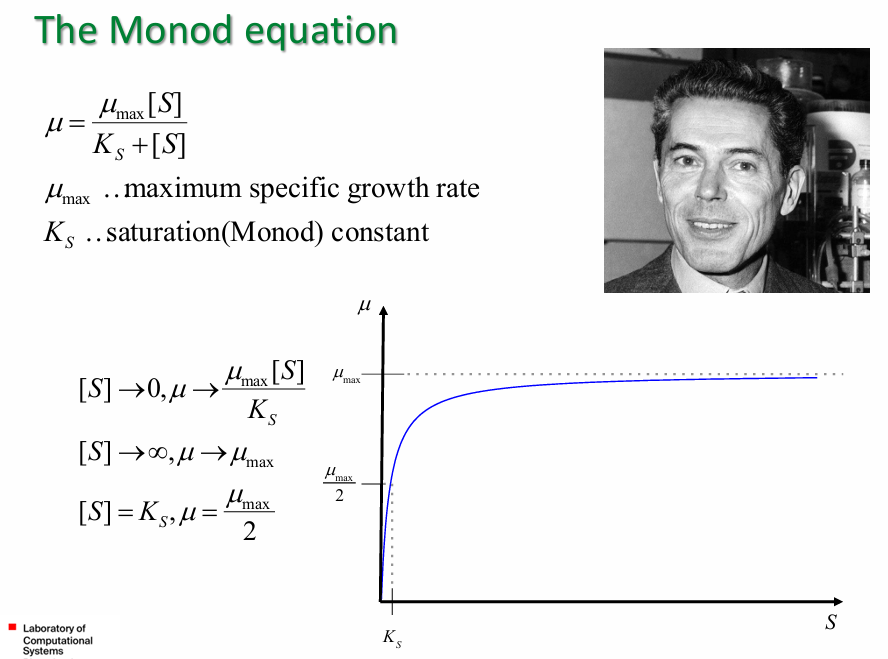

In [8]:
# time doubling
td = np.log(2) / mu_max

print(f"Doubling time td = ln(2) / mu_max = {td:.4f} h = {td*60:.2f} min")

Doubling time td = ln(2) / mu_max = 0.6080 h = 36.48 min
